In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
tables = pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})

In [4]:
for i, table in enumerate(tables):
    print(f"\nТаблиця {i}")
    print(table.head())



Таблиця 0
          0            1
0  Точність  переглянута

Таблиця 1
                                   Населення України  \
0  Статево-вікова піраміда населення України на 1...   
1                                        Чисельність   
2                                            Густота   
3                                Коефіцієнт міграції   
4                                      Природний рух   

                                 Населення України.1  
0  Статево-вікова піраміда населення України на 1...  
1  ▼ 41,130 (1 лютого 2022; без урахування Ар Кри...  
2                                   ▼ 68,2 особи/км²  
3                                             ▲0,9 ‰  
4                                      Природний рух  

Таблиця 2
    0                                                  1
0 NaN  На цьому місці має відображатися графік чи діа...

Таблиця 3
    0                                                  1
0 NaN  На цьому місці має відображатися графік чи діа...

Таблиця 4


In [5]:
df = tables[13]

In [6]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—


In [7]:
print("розмір таблиці")
print(df.shape)

розмір таблиці
(28, 9)


In [8]:
df = df.replace("—", np.nan)

df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,NaN


In [9]:
df.dtypes

,0
Регіон,object
1950,float64
1960,float64
1970,float64
1990,int64
2000,int64
2012,int64
2014,object
2019,object


In [10]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
Регіон,object
1950,float64
1960,float64
1970,float64
1990,int64
2000,int64
2012,int64
2014,float64
2019,float64


In [11]:
missing_percent = df.isnull().sum() / len(df) * 100

print(missing_percent)

Регіон     0.000000
1950       7.142857
1960       3.571429
1970       3.571429
1990       0.000000
2000       0.000000
2012       0.000000
2014       7.142857
2019      14.285714
dtype: float64


In [12]:
df = df.iloc[:-1]

df.tail()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
22,Черкаська,205.0,179.0,144.0,123,75,100,98.0,64.0
23,Чернівецька,247.0,218.0,170.0,148,101,128,129.0,92.0
24,Чернігівська,220.0,183.0,127.0,108,69,94,90.0,61.0
25,Київ,NaN,174.0,159.0,120,73,120,121.0,110.0
26,Севастополь,NaN,NaN,NaN,125,70,120,NaN,NaN


In [13]:
for col in df.columns[1:]:
    df[col] = df[col].fillna(df[col].mean())

df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,111.44,80.173913
1,Вінницька,224.0,192.0,142.0,124,84,112,109.00,76.000000
2,Волинська,247.0,250.0,179.0,153,112,148,141.00,101.000000
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111.00,71.000000
4,Донецька,271.0,214.0,140.0,109,61,98,82.00,80.173913


In [14]:
mean_2019 = df['2019'].mean()

print(mean_2019)

80.17391304347828


In [15]:
higher_birth = df[df['2019'] > mean_2019]
higher_birth[[df.columns[0], '2019']]

,Регіон,2019
2,Волинська,101.0
6,Закарпатська,104.0
8,Івано-Франківська,88.0
12,Львівська,87.0
14,Одеська,88.0
16,Рівненська,107.0
20,Херсонська,81.0
23,Чернівецька,92.0
25,Київ,110.0


In [16]:
max_region = df.loc[df['2014'].idxmax()]
print(max_region[df.columns[0]])
print(max_region['2014'])

Рівненська
148.0


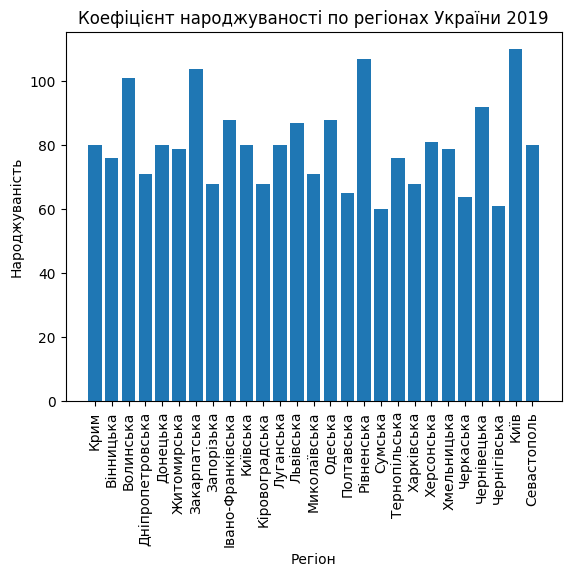

In [17]:
plt.bar(
    df[df.columns[0]],
    df['2019']
)
plt.xticks(rotation=90)
plt.title("Коефіцієнт народжуваності по регіонах України 2019")
plt.ylabel("Народжуваність")
plt.xlabel("Регіон")
plt.show()

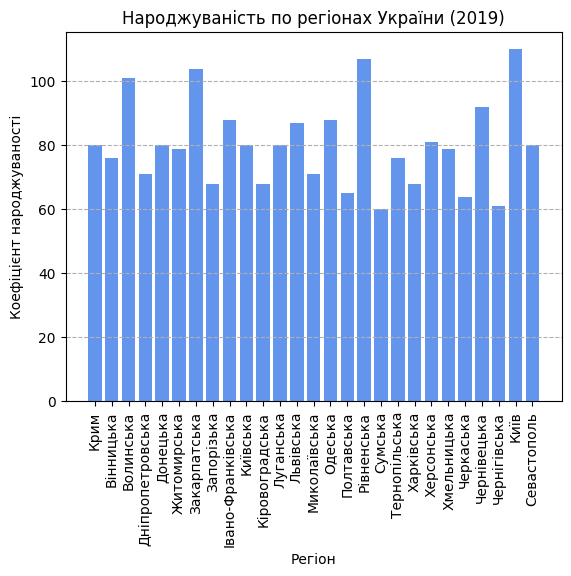

In [18]:
plt.bar(df["Регіон"], df["2019"], color="cornflowerblue")

plt.xticks(rotation=90)
plt.title("Народжуваність по регіонах України (2019)")
plt.xlabel("Регіон")
plt.ylabel("Коефіцієнт народжуваності")
plt.grid(axis="y", linestyle="--")
plt.show()

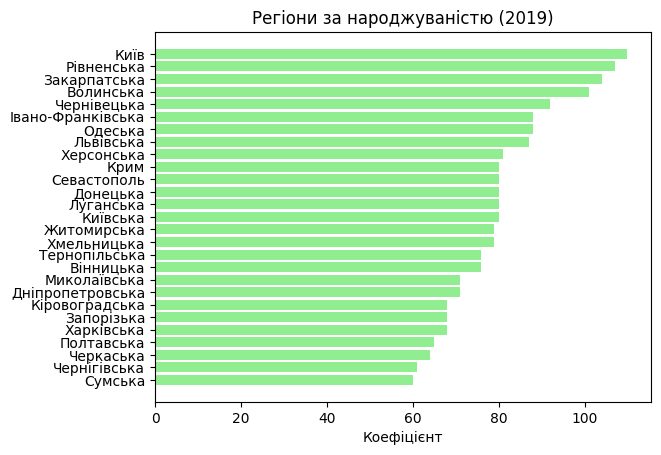

In [19]:
sorted_df = df.sort_values("2019")
plt.barh(sorted_df["Регіон"], sorted_df["2019"], color="lightgreen")
plt.title("Регіони за народжуваністю (2019)")
plt.xlabel("Коефіцієнт")
plt.show()

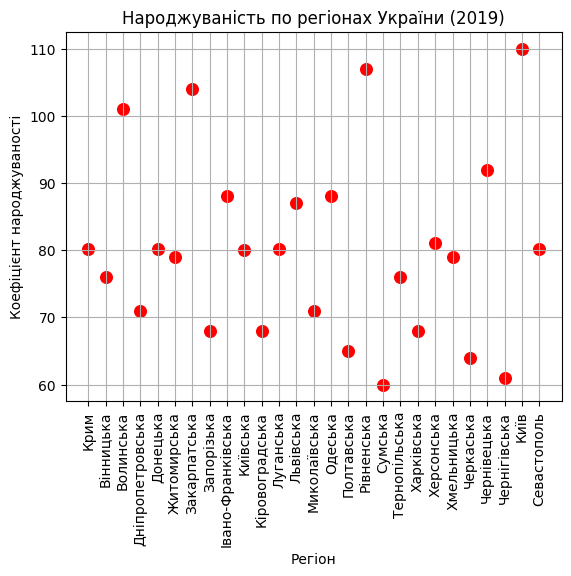

In [22]:
plt.scatter(df["Регіон"], df["2019"], color="red", s=70)
plt.xticks(rotation=90)
plt.title("Народжуваність по регіонах України (2019)")
plt.xlabel("Регіон")
plt.ylabel("Коефіцієнт народжуваності")
plt.grid()
plt.show()